# Figure 1 — SI-2 遗址 ¹⁴C 数据：不同遗址的年代与生业类型

本 notebook **只做拼图**：读取、清洗、按遗址聚合、时间分箱都在带测试的核心模块
`src.workflow.c14` 里（`tests/test_c14.py`，含对随稿附表的钉值测）；这里用
`add_gridspec` 把两个面板拼成一张复合图，手工标注面板字母，存 `dpi=300` PNG +
`.pdf` 矢量孪生。图上文字统一英文。

**这张图要替代的东西**：两样。一是 SI-2 那张 78 行的附表——读者本来要自己在脑子里
把「哪些遗址、什么年代、什么生业」拼起来；成图之后，我们收集的这批生业证据本身就
成了一条可看的论据。二是原来的 Figure 1（Study Area：遗址分布图 + ABM 网格），
它整张撤掉，由本图接替 Figure 1，**不进 SI**。因此正文里再没有图能指遗址位置或
模型景观：位置只剩 SI-2 表里的经纬度列，景观规格只剩 SI-1 ODD+D 的文字描述。
本图只管**年代**和**生业**。

**数据来源**：`data/si2_c14_sites.xlsx`，即随稿投出的 SI-2 附表原件，一字未改。
所有规范化（生业标签拼写、列名）都在加载器里做，原件保持可追溯。

**必须记住的口径**：这是「被测过年代的遗址」的记录，不是人口记录。面板 b 的曲线
读作「有多少个遗址的定年区间覆盖了这一段时间」，不能读作那一段时间有多少人——
它同时受发掘强度、测年经费和保存条件影响。

In [1]:
import sys
from pathlib import Path

import seaborn as sns
from matplotlib import pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "reports":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.workflow import c14  # noqa: E402
from src.workflow import figures as F  # noqa: E402

try:
    from matplotkit import config_font

    config_font("SunTimes")
except Exception as exc:  # 字体缺失不致命，退回默认
    print(f"config_font skipped: {exc}")

sns.set_theme(style="whitegrid", context="notebook")

OUT = PROJECT_ROOT / "reports"
DATASET = PROJECT_ROOT / "data" / "si2_c14_sites.xlsx"

if not DATASET.exists():
    raise FileNotFoundError(
        f"SI-2 附表不存在: {DATASET}\n" "它是随稿投出的原件，应当随仓库一起版本管理。"
    )


def save_fig(fig, name: str) -> None:
    """存图。策略（PNG dpi=300 + 同名 .pdf 孪生）由 src.workflow.figures 统一持有，
    因为 make sync-vault 依赖它；这里只是把 notebook 的输出目录填进去。"""
    F.save_figure(fig, name, OUT)

## 读数据并按遗址聚合

`load_c14_dates` 一行一个测年，`aggregate_sites` 一行一个遗址（按年代中点由老到新
排序，即图上从上到下的顺序）。加载器会在生业标签认不出、或 95.4% 区间方向反了的
时候直接报错，不静默画出一条反向的线。

In [2]:
dates = c14.load_c14_dates(DATASET)
sites = c14.aggregate_sites(dates)
coverage = c14.subsistence_coverage(dates, bin_width=50)

older, younger = c14.overlap_window(coverage)
fraction = c14.coexistence_fraction(dates, coverage)

print(
    f"{len(dates)} dates from {sites.shape[0]} sites in "
    f"{dates['province'].nunique()} provinces"
)
print(sites["subsistence"].value_counts().to_string())
print(f"record spans {dates['cal_from'].max():.0f}-{dates['cal_to'].min():.0f} cal BP")
print(
    f"both livelihoods present {older:.0f}-{younger:.0f} cal BP "
    f"({fraction:.0%} of the record)"
)

sites[["site", "site_zh", "subsistence", "province", "n_dates", "cal_from", "cal_to"]]

78 dates from 26 sites in 3 provinces
subsistence
Foraging    18
Farming      8
record spans 8635-4158 cal BP
both livelihoods present 7575-4325 cal BP (73% of the record)


,site,site_zh,subsistence,province,n_dates,cal_from,cal_to
0,Huiyaotian,灰窑田,Foraging,Guangxi,2,8590,8205
1,Tangdichong,-,Foraging,Guangxi,3,7970,7696
2,Bailiandong,白莲洞,Foraging,Guangxi,1,7965,7511
3,Dapingding,大坪顶,Farming,Fujian,4,7615,7332
4,Liyuzui,鲤鱼嘴,Foraging,Guangxi,2,8635,6279
5,Liyupo,鲤鱼坡,Foraging,Guangxi,5,8032,6740
6,Zengpiyan,甑皮岩,Foraging,Guangxi,1,7579,6964
7,Fuguodun,富国墩,Foraging,Fujian,3,7929,5588
8,Mofancun/Dingmo,模范村/定模,Foraging,Guangxi,5,7932,4658
9,Dahuangsha,大黄沙,Foraging,Guangdong,1,6669,5749


## 成图

**a — 逐遗址年代条**：一行一个遗址，按年代中点由老到新排；粗色段是**每一条**测年的
95.4% 校正区间，细灰线只是该遗址最老到最新的跨度。两者分开画是有意的：Liyuzui 的
两个测年隔了两千多年，若只画一条连线，就会凭空造出一段没有证据的连续占用。颜色
编码生业类型，灰色竖带是正文里农业证据普遍出现的 3500–3000 BC。

**b — 两种生业的时间重叠**：每 50 年一箱，统计各生业类型有多少个**不同遗址**的定年
区间覆盖到该箱（同一遗址的多条测年只算一次）。这一栏把面板 a 的「看起来交错」变成
可以引用的数字：两类生业在记录的绝大部分时间里同时存在。

**它支持正文的哪一句**：农业不是一波推进、把采集狩猎替换掉的；在同一区域、同一段
时间里，两种生业长期并存。这正是模型里 `f2h` / `h2f` 这两条转化通路要刻画的局面——
农业群体一旦落地，面对的不是空白景观，而是一个规模大得多、且一直在那里的采集狩猎
人群。

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/figure1_c14_sites.png  (+ .pdf)


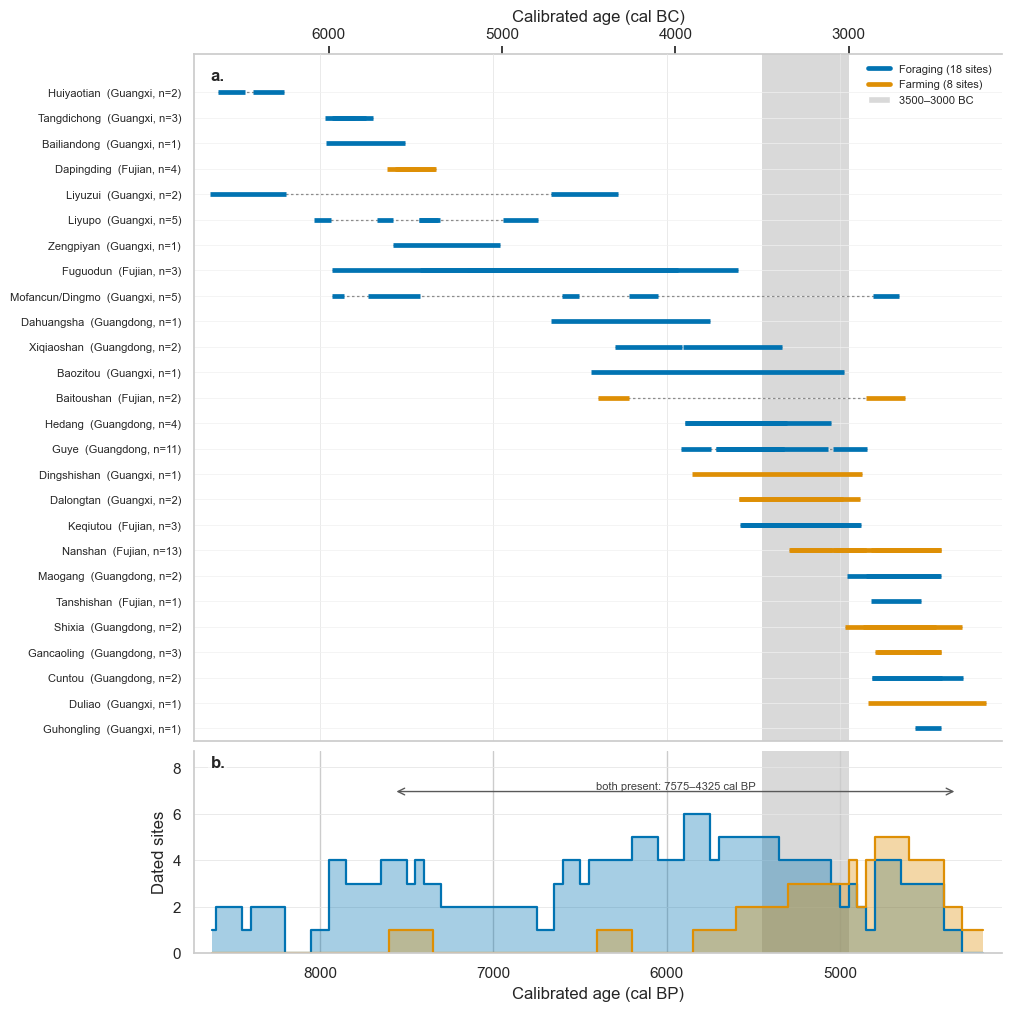

In [3]:
fig = plt.figure(figsize=(10, 10), layout="constrained")
gs = fig.add_gridspec(2, 1, height_ratios=[3.4, 1])

ax_a = fig.add_subplot(gs[0])
c14.plot_site_timeline(dates, sites, ax=ax_a)
c14.add_bce_axis(ax_a)
F.panel_label(ax_a, "a")

ax_b = fig.add_subplot(gs[1], sharex=ax_a)
# 颜色键由面板 a 提供，b 里再放一份既冗余又会和面板字母打架。
c14.plot_subsistence_coverage(coverage, ax=ax_b, legend=False)
F.panel_label(ax_b, "b")

# 两个面板共享横轴，所以只在最下面留一套刻度和轴名。
ax_a.set_xlabel("")
ax_a.tick_params(labelbottom=False)

# 共享轴的范围是拼图层的事：两个 plot_* 各自算的范围略有出入（端点 vs 箱中点），
# 不在这里定死的话，最终范围取决于哪个面板后画。
c14.set_age_xlim(ax_b, dates["cal_from"].max(), dates["cal_to"].min())

save_fig(fig, "figure1_c14_sites")
plt.show();

## 图注草稿（英文，供正文直接取用）

> **Figure 1. Calibrated dates and subsistence type for the South China sites
> compiled in SI-2.** (a) Each row is one site, ordered from oldest to youngest by
> the midpoint of its dated range. Thick bars are the 95.4% calibrated intervals of
> the individual ¹⁴C determinations (n given after each site name); the dashed grey
> line spans a site's oldest to youngest interval and is drawn only to connect them,
> not to assert continuous occupation. Colour gives the subsistence type reported
> for the site. The grey band marks 3500–3000 BC, the interval over which evidence
> for farming becomes widespread across South China. (b) Number of distinct sites
> whose calibrated intervals cover each 50-year bin, by subsistence type; multiple
> determinations from one site are counted once. The arrow marks the interval over
> which both livelihoods are represented. Counts reflect the dated archaeological
> record — excavation and dating effort included — and are not population estimates.
> Site locations, provinces, laboratory codes and references are given in SI 2.

数据与代码：`data/si2_c14_sites.xlsx`（SI-2 原件）→ `src/workflow/c14.py` →
本 notebook。数值由 `tests/test_c14.py` 钉住。